## Callbacks Keras


1. Что такое callback?
2. Для чего callback нужен при обучении нейросети?
3. Рассмотрим основные callback на Keras

Получение данных

Описание датасета:

- CRIM     per capita crime rate by town
- ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
- INDUS    proportion of non-retail business acres per town
- CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
- NOX      nitric oxides concentration (parts per 10 million)
- RM       average number of rooms per dwelling
- AGE      proportion of owner-occupied units built prior to 1940
- DIS      weighted distances to five Boston employment centres
- RAD      index of accessibility to radial highways
- TAX      full-value property-tax rate per 10,000
- PTRATIO  pupil-teacher ratio by town
- B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
- LSTAT    % lower status of the population
- MEDV     Median value of owner-occupied homes in $1000's

In [1]:
from keras.datasets import boston_housing

(X_train, y_train), (X_test, y_test) = boston_housing.load_data()

X_train.shape, X_test.shape

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


((404, 13), (102, 13))

In [2]:
X_train[:1]

array([[  1.23247,   0.     ,   8.14   ,   0.     ,   0.538  ,   6.142  ,
         91.7    ,   3.9769 ,   4.     , 307.     ,  21.     , 396.9    ,
         18.72   ]])

Масштабирование данных

In [3]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

mean, std

(array([3.74511057e+00, 1.14801980e+01, 1.11044307e+01, 6.18811881e-02,
        5.57355941e-01, 6.26708168e+00, 6.90106436e+01, 3.74027079e+00,
        9.44059406e+00, 4.05898515e+02, 1.84759901e+01, 3.54783168e+02,
        1.27408168e+01]),
 array([9.22929073e+00, 2.37382770e+01, 6.80287253e+00, 2.40939633e-01,
        1.17147847e-01, 7.08908627e-01, 2.79060634e+01, 2.02770050e+00,
        8.68758849e+00, 1.66168506e+02, 2.19765689e+00, 9.39946015e+01,
        7.24556085e+00]))

In [4]:
X_train -= mean
X_train /= std

X_test -= mean
X_test /= std

In [5]:
X_train.mean(axis=0)

array([-1.01541438e-16,  1.09923072e-17,  1.74337992e-15, -1.26686340e-16,
       -5.25377321e-15,  6.41414864e-15,  2.98441140e-16,  4.94653823e-16,
        1.12671149e-17, -1.98136337e-16,  2.36686358e-14,  5.95679996e-15,
        6.13920356e-16])

In [6]:
X_train.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

### Архитектура сети


Определение сети через класс Sequential и добавление слоев в него через add

In [7]:
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
tf.random.set_seed(9)


model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1], )))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

### Обучение сети

In [9]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    validation_data=(X_test, y_test))

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - loss: 573.7675 - mae: 22.1940 - val_loss: 592.0854 - val_mae: 22.6336
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 553.1100 - mae: 21.7416 - val_loss: 570.6312 - val_mae: 22.1702
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 531.4595 - mae: 21.2555 - val_loss: 546.3930 - val_mae: 21.6376
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 505.7917 - mae: 20.6708 - val_loss: 517.0311 - val_mae: 20.9834
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 474.4318 - mae: 19.9442 - val_loss: 480.9794 - val_mae: 20.1595
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 436.3180 - mae: 19.0340 - val_loss: 437.2078 - val_mae: 19.1188
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 390.4757 - mae: 17.8910 - val_loss: 385.0192 - val_mae: 17.8034
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 336.5921 - mae: 16.4638 - val_loss: 324.6352 - val_mae: 16.1707
Epoch 9/50
13/13 ━━━

In [10]:
history.history

{'loss': [573.7674560546875,
  553.1100463867188,
  531.4595336914062,
  505.7916564941406,
  474.4317626953125,
  436.3179626464844,
  390.4757080078125,
  336.5921325683594,
  276.54229736328125,
  216.16397094726562,
  161.83834838867188,
  118.74539947509766,
  88.52531433105469,
  68.89893341064453,
  55.93766784667969,
  46.81914138793945,
  40.04949188232422,
  34.98430252075195,
  31.230743408203125,
  28.471202850341797,
  26.438926696777344,
  24.905237197875977,
  23.692527770996094,
  22.700979232788086,
  21.85790252685547,
  21.118053436279297,
  20.435890197753906,
  19.82217788696289,
  19.2501277923584,
  18.726003646850586,
  18.23470687866211,
  17.769304275512695,
  17.334815979003906,
  16.928049087524414,
  16.554487228393555,
  16.187610626220703,
  15.847928047180176,
  15.526471138000488,
  15.222683906555176,
  14.941760063171387,
  14.663503646850586,
  14.400125503540039,
  14.159048080444336,
  13.915277481079102,
  13.681567192077637,
  13.4667329788208,
 

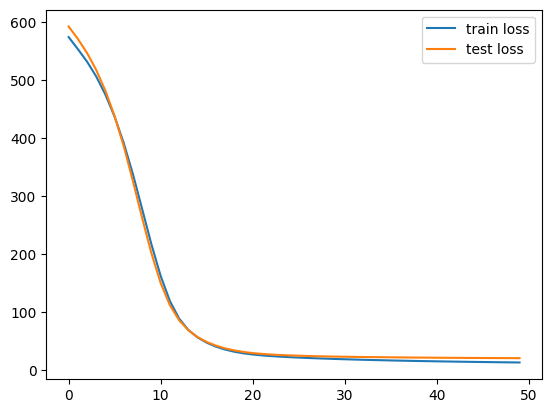

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='test loss')
plt.legend();

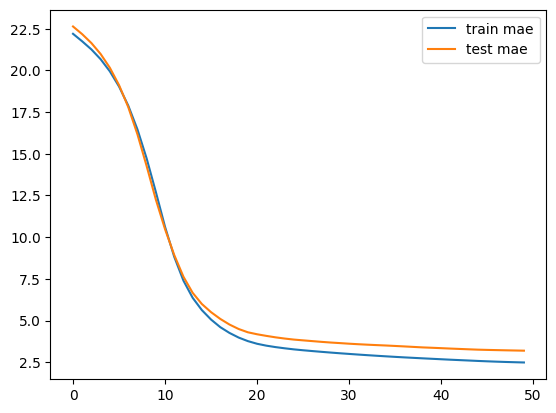

In [12]:
plt.plot(history.history['mae'], label='train mae')
plt.plot(history.history['val_mae'], label='test mae')
plt.legend();

### Callbacks

> callbacks: List of `keras.callbacks.Callback` instances.<br>
        List of callbacks to apply during training.<br>
        See `tf.keras.callbacks`. Note `tf.keras.callbacks.ProgbarLogger`
        and `tf.keras.callbacks.History` callbacks are created automatically
        and need not be passed into `model.fit`.

Callback (обратные вызовы) – набор функций, применяемых в определенные моменты во время процедуры обучения. Вы можете использовать функции callback чтобы получить информацию о внутреннем состоянии модели в процессе обучения. Нужно передавать список callback’ов (именованным аргументом callbacks) методу .fit() модели. Подходящие методы callback будут вызваны на каждой стадии обучения.

Рассмотрим основные callback'и, с остальными можете ознакомиться в [документации](https://ru-keras.com/callbacks/).

#### ModelCheckpoint


Сохранение модели после каждой эпохи.

Filepath может содержать именованные опции форматирования, заполняемые значениями epoch и ключами в logs (передаваемыми on_epoch_end).

К примеру: если filepath назван weights.{epoch:02d}-{val_loss:.2f}.hdf5, тогда модель будет сохраняться с номером эпохи и validation_loss в имени файла.

**Аргументы:**

— filepath: строка, путь сохранения модели

— monitor: параметр для мониторинга

— verbose: режим отображения, 0 или 1

— save_best_only: если save_best_only=True, если результат текущей эпохи хуже предыдущей, он не будет сохранен.

— save_weights_only: если True, тогда будут сохраняться только веса модели (model.save_weights(filepath)), в противном случае будет сохраняться вся модель (model.save(filepath)).

— mode: один из {auto, min, max}. Если save_best_only=True, решение о перезаписи текущего файла будет приниматься в зависимости от уменьшения/увеличения параметра мониторинга. Для val_acc, необходим max, для val_loss необходим min. В auto режиме, mode выбирается в зависимости от имени monitor.

— save_freq: `'epoch'` или integer. Если `'epoch'`, то сохраняется модель после каждой эпохиh. Когда integer, то сохранение модели через это кол-во батчей.


In [13]:
from keras import callbacks

model_checkpoint = callbacks.ModelCheckpoint(filepath='model_best_{epoch}.h5',
                                             monitor='val_mae',
                                             verbose=1,
                                             save_best_only=True,
                                             save_weights_only=False,
                                             mode='auto',
                                             save_freq='epoch'
                                             )

In [14]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [15]:
model.fit(X_train, y_train,
          epochs=5,
          validation_data=(X_test, y_test),
          callbacks=[model_checkpoint])

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 14.4653 - mae: 2.4970
Epoch 1: val_mae improved from None to 3.17985, saving model to model_best_1.h5



Epoch 1: finished saving model to model_best_1.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 12.8071 - mae: 2.4990 - val_loss: 20.2250 - val_mae: 3.1798
Epoch 2/5
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8.0650 - mae: 2.0715
Epoch 2: val_mae improved from 3.17985 to 3.16044, saving model to model_best_2.h5



Epoch 2: finished saving model to model_best_2.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12.2708 - mae: 2.4631 - val_loss: 20.1056 - val_mae: 3.1604
Epoch 3/5
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 7.5248 - mae: 1.9926
Epoch 3: val_mae improved from 3.16044 to 3.14192, saving model to model_best_3.h5



Epoch 3: finished saving model to model_best_3.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12.0164 - mae: 2.4233 - val_loss: 19.9794 - val_mae: 3.1419
Epoch 4/5
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 7.4419 - mae: 1.9892
Epoch 4: val_mae improved from 3.14192 to 3.12525, saving model to model_best_4.h5



Epoch 4: finished saving model to model_best_4.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 11.7692 - mae: 2.4020 - val_loss: 19.8832 - val_mae: 3.1253
Epoch 5/5
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 7.4584 - mae: 2.0023
Epoch 5: val_mae improved from 3.12525 to 3.11414, saving model to model_best_5.h5



Epoch 5: finished saving model to model_best_5.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 11.5471 - mae: 2.3810 - val_loss: 19.8327 - val_mae: 3.1141


#### EarlyStopping


Прекращение обучения, когда параметр monitor перестает улучшаться.

**Аргументы**

— monitor: параметр для мониторинга

— min_delta: минимальное значение изменения величины monitor, расцениваемое как улучшение, то есть, если абсолютное изменение меньше min_delta, то улучшение не засчитывается

— patience: число эпох, за которые величина monitor не улучшается, после которых обучение будет остановлено. Проверочные величины могут производиться не после каждой эпохи если validation_freq (model.fit(validation_freq=5)) больше единицы.

— verbose: режим отображения, 0 или 1.

— mode: один из {auto, min, max}. В режиме min, обучение остановится когда величина monitor перестанет уменьшаться; в режиме max, обучение остановится когда величина monitor перестанет увеличиваться; в режиме auto, mode выбирается в зависимости от имени monitor.

— baseline: значение, которое должна достичь величина monitor. Обучение прекратится, если модель не достигла baseline.

— restore_best_weights: восстанавливать ли веса модели с эпохи с лучшем значением параметра monitor. Если False, веса модели будут загружены из последней шага обучения.

In [16]:
early_stop = callbacks.EarlyStopping(monitor='val_loss',
                                     min_delta=0,
                                     patience=2,
                                     verbose=1,
                                     mode='auto',
                                    #baseline=0.006,
                                     restore_best_weights=True)


model.fit(X_train, y_train,
          epochs=10,
          validation_data=(X_test, y_test),
          callbacks=[early_stop])

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 11.3335 - mae: 2.3604 - val_loss: 19.7512 - val_mae: 3.0980
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 11.1453 - mae: 2.3426 - val_loss: 19.7311 - val_mae: 3.0863
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 10.9627 - mae: 2.3256 - val_loss: 19.7235 - val_mae: 3.0753
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 10.7914 - mae: 2.3093 - val_loss: 19.7032 - val_mae: 3.0642
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 10.6287 - mae: 2.2939 - val_loss: 19.6903 - val_mae: 3.0531
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 10.4766 - mae: 2.2788 - val_loss: 19.6707 - val_mae: 3.0416
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 10.3357 - mae: 2.2648 - val_loss: 19.6665 - val_mae: 3.0326
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 10.1979 - mae: 2.2516 - val_loss: 19.6472 - val_mae: 3.0254
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step 

#### ReduceLROnPlateau

Уменьшение скорости обучения, когда метрика перестала улучшаться.

Модели зачастую работают лучше если уменьшать скорость обучения. Этот callback следит за параметром monitor и, если не происходит улучшения за patience эпох, уменьшает скорость обучения.


**Аргументы**

— monitor:  параметр для мониторинга

— factor: коэффициент уменьшения скорости обучения. new_lr = lr * factor

— patience: число эпох, за которые величина monitor не улучшается, после которых обучение будет остановлено. Проверочные величины могут производиться не после каждой эпохи если validation_freq (model.fit(validation_freq=5)) больше единицы.

— verbose: int. 0: «тихий» режим, 1: выводить сообщения

— mode: один из {auto, min, max}. В режиме min, скорость обучения уменьшится когда величина monitor перестанет уменьшаться; в режиме max, скорость обучения уменьшится когда величина monitor перестанет увеличиваться; в режиме auto, mode выбирается в зависимости от имени monitor.

— min_delta: минимальное значение изменения величины monitor, расцениваемое как улучшение, то есть, если абсолютное изменение меньше min_delta, то улучшение не засчитывается

— cooldown: число эпох после уменьшения скорости обучения, которые должны пройти, прежде чем стандартный процесс уменьшения возобновится.

— min_lr: нижняя граница скорости обучения

In [17]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [18]:
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_mae',
                                        factor=0.1,
                                        patience=0,
                                        verbose=1,
                                        mode='auto',
                                        min_delta=0,
                                        cooldown=2,
                                        min_lr=1e-10)

model.fit(X_train, y_train,
          epochs=10,
          validation_data=(X_test, y_test),
          callbacks=[reduce_lr])

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 10.0953 - mae: 2.2432 - val_loss: 19.7939 - val_mae: 3.0006 - learning_rate: 0.0010
Epoch 2/10
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 7.0579 - mae: 1.9808
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.7476 - mae: 2.2089 - val_loss: 19.7543 - val_mae: 3.0095 - learning_rate: 0.0010
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.6091 - mae: 2.1835 - val_loss: 19.7595 - val_mae: 3.0096 - learning_rate: 1.0000e-04
Epoch 4/10
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 6.6390 - mae: 1.9030
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.5962 - mae: 2.1827 - val_loss: 19.7613 - val_mae: 3.0087 - learning_rate: 1.0000e-04
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.5800 - mae: 2.1815 - val_loss: 19.7616 - val_mae: 3.0086 - learning_rate: 

#### Кастомный callback

In [19]:
import keras

class CustomCallback(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        keys = list(logs.keys())
        print(f"Starting training; got log keys: {keys}")

    def on_train_end(self, logs=None):
        keys = list(logs.keys())
        print(f"Stop training; got log keys: {keys}")

    def on_epoch_begin(self, epoch, logs=None):
        keys = list(logs.keys())
        print(f"Start epoch {epoch} of training; got log keys: {keys}")

    def on_epoch_end(self, epoch, logs=None):
        keys = list(logs.keys())
        print(f"End epoch {epoch} of training; got log keys: {keys}")

    def on_test_begin(self, logs=None):
        keys = list(logs.keys())
        print(f"Start testing; got log keys: {keys}")

    def on_test_end(self, logs=None):
        keys = list(logs.keys())
        print(f"Stop testing; got log keys: {keys}")

    def on_train_batch_begin(self, batch, logs=None):
        keys = list(logs.keys())
        print(f"...Training: start of batch {batch}; got log keys: {keys}")

    def on_train_batch_end(self, batch, logs=None):
        keys = list(logs.keys())
        print(f"...Training: end of batch {batch}; got log keys: {keys}")

    def on_test_batch_begin(self, batch, logs=None):
        keys = list(logs.keys())
        print(f"...Evaluating: start of batch {batch}; got log keys: {keys}")

    def on_test_batch_end(self, batch, logs=None):
        keys = list(logs.keys())
        print(f"...Evaluating: end of batch {batch}; got log keys: {keys}")

In [20]:
model.fit(X_train, y_train,
          epochs=1,
          validation_data=(X_test, y_test),
          callbacks=[CustomCallback()],
          verbose=0);

Starting training; got log keys: []
Start epoch 0 of training; got log keys: []
...Training: start of batch 0; got log keys: []
...Training: end of batch 0; got log keys: ['loss', 'mae']
...Training: start of batch 1; got log keys: []
...Training: end of batch 1; got log keys: ['loss', 'mae']
...Training: start of batch 2; got log keys: []
...Training: end of batch 2; got log keys: ['loss', 'mae']
...Training: start of batch 3; got log keys: []
...Training: end of batch 3; got log keys: ['loss', 'mae']
...Training: start of batch 4; got log keys: []
...Training: end of batch 4; got log keys: ['loss', 'mae']
...Training: start of batch 5; got log keys: []
...Training: end of batch 5; got log keys: ['loss', 'mae']
...Training: start of batch 6; got log keys: []
...Training: end of batch 6; got log keys: ['loss', 'mae']
...Training: start of batch 7; got log keys: []
...Training: end of batch 7; got log keys: ['loss', 'mae']
...Training: start of batch 8; got log keys: []
...Training: end

In [21]:
from IPython.display import clear_output
import time


class LossAndErrorPrintingCallback(keras.callbacks.Callback):
    def on_train_batch_end(self, batch, logs=None):
        print(
            f'...Train: batch {batch}, the average loss is {logs["loss"]:5.2f}'
        )

    def on_test_batch_end(self, batch, logs=None):
        print(
            f'...Test: batch {batch}, the average loss is {logs["loss"]:7.2f}'
        )

    def on_epoch_begin(self, epoch, logs=None):
        print(
            f"Start epoch {epoch}; You're doing great, honey!\n"
        )

    def on_epoch_end(self, epoch, logs=None):
        print(
            f'\nThe average loss for epoch {epoch} is {logs["loss"]:7.2f} '
            f'and mean absolute error is {logs["mae"]:7.2f}.'
        )

In [22]:
model.fit(X_train, y_train,
          epochs=1,
          validation_data=(X_test, y_test),
          callbacks=[LossAndErrorPrintingCallback()],
          verbose=0);

Start epoch 0; You're doing great, honey!

...Train: batch 0, the average loss is  6.67
...Train: batch 1, the average loss is 17.68
...Train: batch 2, the average loss is 14.02
...Train: batch 3, the average loss is 12.64
...Train: batch 4, the average loss is 12.12
...Train: batch 5, the average loss is 11.10
...Train: batch 6, the average loss is 10.84
...Train: batch 7, the average loss is 10.71
...Train: batch 8, the average loss is 10.10
...Train: batch 9, the average loss is  9.91
...Train: batch 10, the average loss is  9.73
...Train: batch 11, the average loss is  9.68
...Train: batch 12, the average loss is  9.58
...Test: batch 0, the average loss is   10.53
...Test: batch 1, the average loss is   12.81
...Test: batch 2, the average loss is   13.38
...Test: batch 3, the average loss is   19.76

The average loss for epoch 0 is    9.58 and mean absolute error is    2.18.


#####**self.model.stop_training = True**

прекращает обучение модели

In [23]:
class LossAndErrorPrintingCallback(keras.callbacks.Callback):
    def on_train_batch_end(self, batch, logs=None):
        print(
            f'...Train: batch {batch}, the average loss is {logs["loss"]:5.2f}'
        )

        if batch == 4:
            self.model.stop_training = True
            print('Model is tired. Stop it')

    def on_test_batch_end(self, batch, logs=None):
        print(
            f'...Test: batch {batch}, the average loss is {logs["loss"]:7.2f}'
        )

    def on_epoch_begin(self, epoch, logs=None):
        print(
            f"Start epoch {epoch}; You're doing great, honey!\n"
        )

    def on_epoch_end(self, epoch, logs=None):
        print(
            f'\nThe average loss for epoch {epoch} is {logs["loss"]:7.2f} '
            f'and mean absolute error is {logs["mae"]:7.2f}.'
        )

In [24]:
model.fit(X_train, y_train,
          epochs=2,
          validation_data=(X_test, y_test),
          callbacks=[LossAndErrorPrintingCallback()],
          verbose=0);

Start epoch 0; You're doing great, honey!

...Train: batch 0, the average loss is  6.67
...Train: batch 1, the average loss is 17.68
...Train: batch 2, the average loss is 14.02
...Train: batch 3, the average loss is 12.64
...Train: batch 4, the average loss is 12.12
Model is tired. Stop it
...Test: batch 0, the average loss is   10.53
...Test: batch 1, the average loss is   12.81
...Test: batch 2, the average loss is   13.38
...Test: batch 3, the average loss is   19.76

The average loss for epoch 0 is   12.12 and mean absolute error is    2.23.


##### **self.model.predict()**

Получать предсказания модели


In [25]:

class LossAndErrorPrintingCallback(keras.callbacks.Callback):
    def on_train_batch_end(self, batch, logs=None):
        print(
            f'...Train: batch {batch}, the average loss is {logs["loss"]:5.2f}'
        )

    def on_test_batch_end(self, batch, logs=None):
        print(
            f'...Test: batch {batch}, the average loss is {logs["loss"]:7.2f}'
        )

    def on_epoch_begin(self, epoch, logs=None):

        pred = self.model.predict(X_test[:1])

        print(f'Model prediction is {pred[0][0]}. True is {y_test[0]}')
        print(
            f"Start epoch {epoch}; You're doing great, honey!\n"
        )

    def on_epoch_end(self, epoch, logs=None):
        print(
            f'\nThe average loss for epoch {epoch} is {logs["loss"]:7.2f} '
            f'and mean absolute error is {logs["mae"]:7.2f}.'
        )

In [26]:
model.fit(X_train, y_train,
          epochs=2,
          validation_data=(X_test, y_test),
          callbacks=[LossAndErrorPrintingCallback()],
          verbose=0);

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
Model prediction is 7.612745761871338. True is 7.2
Start epoch 0; You're doing great, honey!

...Train: batch 0, the average loss is  6.67
...Train: batch 1, the average loss is 17.68
...Train: batch 2, the average loss is 14.02
...Train: batch 3, the average loss is 12.64
...Train: batch 4, the average loss is 12.12
...Train: batch 5, the average loss is 11.10
...Train: batch 6, the average loss is 10.84
...Train: batch 7, the average loss is 10.71
...Train: batch 8, the average loss is 10.10
...Train: batch 9, the average loss is  9.91
...Train: batch 10, the average loss is  9.73
...Train: batch 11, the average loss is  9.68
...Train: batch 12, the average loss is  9.58
...Test: batch 0, the average loss is   10.53
...Test: batch 1, the average loss is   12.81
...Test: batch 2, the average loss is   13.38
...Test: batch 3, the average loss is   19.76

The average loss for epoch 0 is    9.58 and mean absolute error is    2.18.
1/1 ━━━━━━━━━━━━━━

##### Делать визуализации и чистить экран

In [27]:
from IPython.display import clear_output
import time


class LossAndErrorPrintingCallback(keras.callbacks.Callback):
    def on_train_batch_end(self, batch, logs=None):
        print(
            f'...Train: batch {batch}, the average loss is {logs["loss"]:5.2f}'
        )
        time.sleep(0.5)

    def on_test_batch_end(self, batch, logs=None):
        print(
            f'...Test: batch {batch}, the average loss is {logs["loss"]:7.2f}'
        )

    def on_epoch_begin(self, epoch, logs=None):
        print(
            f"Start epoch {epoch}; You're doing great, honey!\n"
        )

    def on_epoch_end(self, epoch, logs=None):
        print(
            f'\nThe average loss for epoch {epoch} is {logs["loss"]:7.2f} '
            f'and mean absolute error is {logs["mae"]:7.2f}.'
        )
        print('\nIn 2 seconds screen will be clear')
        time.sleep(4)
        clear_output(wait=True)

In [ ]:
model.fit(X_train, y_train,
          epochs=2,
          validation_data=(X_test, y_test),
          callbacks=[LossAndErrorPrintingCallback()],
          verbose=0);

Start epoch 0; You're doing great, honey!

...Train: batch 0, the average loss is  6.67
...Train: batch 1, the average loss is 17.68
...Train: batch 2, the average loss is 14.02
...Train: batch 3, the average loss is 12.64
...Train: batch 4, the average loss is 12.12
...Train: batch 5, the average loss is 11.10
...Train: batch 6, the average loss is 10.84
...Train: batch 7, the average loss is 10.71
...Train: batch 8, the average loss is 10.10
...Train: batch 9, the average loss is  9.91
...Train: batch 10, the average loss is  9.73
...Train: batch 11, the average loss is  9.68
...Train: batch 12, the average loss is  9.58
...Test: batch 0, the average loss is   10.53
...Test: batch 1, the average loss is   12.81
...Test: batch 2, the average loss is   13.38
...Test: batch 3, the average loss is   19.76

The average loss for epoch 0 is    9.58 and mean absolute error is    2.18.

In 2 seconds screen will be clear
Start epoch 1; You're doing great, honey!

...Train: batch 0, the average

Можно изменять параметры оптимизатора **self.model.optimizer.learning_rate**
